# KuaiRand-Pure 推荐策略业务深化分析

前期描述性分析已经比较了两种推荐方式的总体点击率、长播率、完播率、互动率、播放时长中位数和播放进度中位数。本 Notebook是在既有结论之上回答更接近业务决策的问题：

> 已有总体差异在点击后条件口径和同用户等权口径下是否仍然存在？差异集中在哪些用户和内容分层，已观测样本构成能否解释这些差异，又应如何设计实验验证策略假设？

分析采用三层证据：

1. **基线复算与新增点击后质量**：已有曝光层指标只用于核对基线，新增点击后条件指标用于区分“点击更多”和“点击后质量更高”，同时不强行构造不成立的线性漏斗。
2. **共同用户配对验证**：对同时出现在两种推荐方式中的用户进行等权比较，并以用户为重采样单位计算 95% Bootstrap 置信区间。
3. **分层与构成校正**：比较用户/内容分层内部差异，并使用共同构成权重检验总体差异是否主要由样本构成造成。

> 边界：该数据不是用户级随机分流实验。所有结果均为观察性关联，不使用“导致”“提升”等因果措辞。

## 一、环境与数据口径

- 同期范围：2022-04-22 至 2022-05-08。
- 标准推荐和随机推荐分别清洗、去重后再比较。
- 完播只在视频时长有效的记录中计算。
- 正向互动指点赞、评论、关注、转发任一发生。
- 负反馈使用 `is_hate`。
- 小样本分层保留展示，但不进入稳定策略结论。

In [1]:
from pathlib import Path
import gc

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display


def find_project_root(start: Path | None = None) -> Path:
    """从当前目录向上寻找 KuaiRand_Pure 项目根目录。"""
    start = (start or Path.cwd()).resolve()
    for candidate in (start, *start.parents):
        if (candidate / "Python").is_dir() and (candidate / "data" / "raw").is_dir():
            return candidate
    raise FileNotFoundError("未找到 KuaiRand_Pure 项目根目录")


PROJECT_ROOT = find_project_root()
RAW_DIR = PROJECT_ROOT / "data" / "raw"
OUTPUT_DIR = PROJECT_ROOT / "outputs" / "business_analysis"
FIGURE_DIR = PROJECT_ROOT / "outputs" / "figures"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
plt.rcParams["font.sans-serif"] = ["Microsoft YaHei", "SimHei", "Arial Unicode MS"]
plt.rcParams["axes.unicode_minus"] = False

COLORS = {
    "standard": "#F28E2B",
    "random": "#4E79A7",
    "positive": "#2A9D8F",
    "negative": "#D1495B",
}

print("项目根目录：", PROJECT_ROOT)

项目根目录： E:\Users\yanyan\Desktop\KuaiRand_Pure


In [2]:
BEHAVIOR_KEEP = [
    "user_id", "video_id", "is_click", "is_like", "is_follow",
    "is_comment", "is_forward", "is_hate", "long_view",
    "play_time_ms", "duration_ms", "is_profile_enter"
]

BINARY_COLS = [
    "is_click", "is_like", "is_follow", "is_comment",
    "is_forward", "is_hate", "long_view", "is_profile_enter"
]


def load_clean_log(path: Path, method: str) -> tuple[pd.DataFrame, dict]:
    """按 01 Notebook 已验证的规则去重并构造分析字段。"""
    raw = pd.read_csv(path)
    audit = {
        "method": method,
        "raw_rows": len(raw),
        "duplicate_rows": int(raw.duplicated().sum()),
    }

    data = (
        raw.drop_duplicates()
        .reset_index(drop=True)[BEHAVIOR_KEEP]
        .copy()
    )
    audit["clean_rows"] = len(data)

    data["user_id"] = pd.to_numeric(data["user_id"], downcast="integer")
    data["video_id"] = pd.to_numeric(data["video_id"], downcast="integer")
    data["play_time_ms"] = pd.to_numeric(data["play_time_ms"], downcast="integer")
    data["duration_ms"] = pd.to_numeric(data["duration_ms"], downcast="integer")

    for col in BINARY_COLS:
        data[col] = data[col].astype("int8")

    interaction_cols = ["is_like", "is_comment", "is_follow", "is_forward"]
    data["has_interaction"] = (
        data[interaction_cols].eq(1).any(axis=1).astype("int8")
    )

    valid_duration = data["duration_ms"].gt(0)
    data["is_complete_play"] = pd.Series(
        pd.NA, index=data.index, dtype="Int8"
    )
    data.loc[valid_duration, "is_complete_play"] = (
        data.loc[valid_duration, "play_time_ms"]
        >= data.loc[valid_duration, "duration_ms"]
    ).astype("int8")

    data["play_time_seconds"] = data["play_time_ms"] / 1000.0
    data["recommendation_method"] = method

    del raw
    gc.collect()
    return data, audit


standard, standard_audit = load_clean_log(
    RAW_DIR / "log_standard_4_22_to_5_08_pure.csv",
    "standard",
)
random_data, random_audit = load_clean_log(
    RAW_DIR / "log_random_4_22_to_5_08_pure.csv",
    "random",
)

display(standard_audit)
display(random_audit)

assert len(standard) == 289_119
assert len(random_data) == 1_186_049

user_dim = pd.read_csv(
    RAW_DIR / "user_features_pure.csv",
    usecols=["user_id", "user_active_degree", "register_days"],
)
video_dim = pd.read_csv(
    RAW_DIR / "video_features_basic_pure.csv",
    usecols=[
        "video_id", "video_type", "upload_type", "video_duration",
        "server_width", "server_height"
    ],
)

assert not user_dim["user_id"].duplicated().any()
assert not video_dim["video_id"].duplicated().any()

user_dim["register_days_group"] = pd.cut(
    user_dim["register_days"],
    bins=[0, 180, 365, 730, 1460, np.inf],
    labels=["半年以内", "半年-1年", "1-2年", "2-4年", "4年以上"],
    right=False,
    include_lowest=True,
)

video_dim["video_duration_seconds"] = video_dim["video_duration"] / 1000.0
video_dim["duration_group"] = pd.cut(
    video_dim["video_duration_seconds"],
    bins=[0, 15, 30, 60, 120, np.inf],
    labels=["0-15秒", "15-30秒", "30-60秒", "60-120秒", "120秒以上"],
    right=False,
    include_lowest=True,
)

video_dim["screen_orientation"] = np.select(
    [
        video_dim["server_width"] > video_dim["server_height"],
        video_dim["server_width"] < video_dim["server_height"],
        video_dim["server_width"] == video_dim["server_height"],
    ],
    ["横屏", "竖屏", "方形"],
    default="缺失",
)


def enrich(data: pd.DataFrame) -> pd.DataFrame:
    rows_before = len(data)
    out = (
        data.merge(
            user_dim,
            on="user_id",
            how="left",
            validate="many_to_one",
            indicator="user_join",
        )
        .merge(
            video_dim,
            on="video_id",
            how="left",
            validate="many_to_one",
            indicator="video_join",
        )
    )
    assert len(out) == rows_before
    assert out["user_join"].eq("both").all()
    assert out["video_join"].eq("both").all()
    return out.drop(columns=["user_join", "video_join"])


standard = enrich(standard)
random_data = enrich(random_data)
all_data = pd.concat([standard, random_data], ignore_index=True)

audit_table = pd.DataFrame([standard_audit, random_audit])
display(audit_table)
print("合并分析表：", all_data.shape)

{'method': 'standard',
 'raw_rows': 295497,
 'duplicate_rows': 6378,
 'clean_rows': 289119}

{'method': 'random',
 'raw_rows': 1186059,
 'duplicate_rows': 10,
 'clean_rows': 1186049}

,method,raw_rows,duplicate_rows,clean_rows
0,standard,295497,6378,289119
1,random,1186059,10,1186049


合并分析表： (1475168, 27)


## 二、数据适用性审计

这里先判断“能不能这样分析”，再计算指标。

严格线性漏斗要求后一阶段必然属于前一阶段，但本数据存在少量未点击却长播、完播或互动的记录。因此本项目采用：

> 曝光 → 点击/有效播放，随后并列观察长播、完播、正向互动、负反馈。

这是一棵推荐质量树，而不是强行串联的交易漏斗。

In [3]:
common_users = np.intersect1d(
    standard["user_id"].unique(),
    random_data["user_id"].unique(),
)

standard_pairs = standard[["user_id", "video_id"]].drop_duplicates()
random_pairs = random_data[["user_id", "video_id"]].drop_duplicates()
common_pair_count = (
    standard_pairs.merge(
        random_pairs,
        on=["user_id", "video_id"],
        how="inner",
        validate="one_to_one",
    ).shape[0]
)

violation_rows = []
for method, data in [
    ("standard", standard),
    ("random", random_data),
]:
    violation_rows.append({
        "recommendation_method": method,
        "recommendation_records": len(data),
        "long_view_without_click": int(
            ((data["long_view"] == 1) & (data["is_click"] == 0)).sum()
        ),
        "complete_without_click": int(
            ((data["is_complete_play"] == 1) & (data["is_click"] == 0)).sum()
        ),
        "interaction_without_click": int(
            ((data["has_interaction"] == 1) & (data["is_click"] == 0)).sum()
        ),
    })

data_scope_audit = pd.DataFrame(violation_rows)

print("共同用户数：", len(common_users))
print("共同用户—视频组合数：", common_pair_count)
display(data_scope_audit)

del standard_pairs, random_pairs
gc.collect()

共同用户数： 25877
共同用户—视频组合数： 136


,recommendation_method,recommendation_records,long_view_without_click,complete_without_click,interaction_without_click
0,standard,289119,325,130,999
1,random,1186049,365,80,2396


0

## 三、基线复算与新增点击后质量口径

曝光层点击率、长播率、完播率和互动率在前期描述性分析中已经完成比较，本节复算它们只是为了核对同期样本基线，不计入本轮新增贡献。

点击后条件指标是本节新增口径，用于回答“用户开始播放后，观看和互动质量如何”。

两类口径不能混用：

- 曝光层：分母是全部推荐记录。
- 点击后：分母是点击记录；点击后完播还要求视频时长有效。

**QUALITY_SPECS**是**指标规则计算清单**，这样做的目的是为了：

同一个计算框架只需要依次取出：
- 指标名称；
- 指标阶段；
- 分母条件；
- 分子条件。

就可以计算不同指标，不必为每个指标重复写一套完整流程。

In [4]:
QUALITY_SPECS = [
    ("点击/有效播放率", "exposure", lambda d: pd.Series(True, index=d.index), lambda d: d["is_click"].eq(1)),
    ("长播率", "exposure", lambda d: pd.Series(True, index=d.index), lambda d: d["long_view"].eq(1)),
    ("完整播放率", "exposure", lambda d: d["is_complete_play"].notna(), lambda d: d["is_complete_play"].eq(1)),
    ("正向互动率", "exposure", lambda d: pd.Series(True, index=d.index), lambda d: d["has_interaction"].eq(1)),
    ("负反馈率", "exposure", lambda d: pd.Series(True, index=d.index), lambda d: d["is_hate"].eq(1)),
    ("进入主页率", "exposure", lambda d: pd.Series(True, index=d.index), lambda d: d["is_profile_enter"].eq(1)),
    ("点击后长播率", "post_click", lambda d: d["is_click"].eq(1), lambda d: d["long_view"].eq(1)),
    ("点击后完整播放率", "post_click", lambda d: d["is_click"].eq(1) & d["is_complete_play"].notna(), lambda d: d["is_complete_play"].eq(1)),
    ("点击后正向互动率", "post_click", lambda d: d["is_click"].eq(1), lambda d: d["has_interaction"].eq(1)),
    ("点击后负反馈率", "post_click", lambda d: d["is_click"].eq(1), lambda d: d["is_hate"].eq(1)),
]


def quality_long(data: pd.DataFrame, method: str) -> pd.DataFrame:
    rows = []
    for metric, metric_level, denominator_fn, numerator_fn in QUALITY_SPECS:
        denominator_mask = denominator_fn(data)
        numerator_mask = denominator_mask & numerator_fn(data)
        denominator = int(denominator_mask.sum())
        numerator = int(numerator_mask.sum())
        rows.append({
            "metric": metric,
            "metric_level": metric_level,
            "recommendation_method": method,
            "numerator": numerator,
            "denominator": denominator,
            "rate_pct": numerator / denominator * 100 if denominator else np.nan,
        })
    return pd.DataFrame(rows)


quality_long_table = pd.concat(
    [
        quality_long(standard, "standard"),
        quality_long(random_data, "random"),
    ],
    ignore_index=True,
)

display(quality_long_table)

,metric,metric_level,recommendation_method,numerator,denominator,rate_pct
0,点击/有效播放率,exposure,standard,130442,289119,45.1171
1,长播率,exposure,standard,92035,289119,31.8329
2,完整播放率,exposure,standard,40728,284321,14.3247
3,正向互动率,exposure,standard,6196,289119,2.1431
4,负反馈率,exposure,standard,227,289119,0.0785
5,进入主页率,exposure,standard,5490,289119,1.8989
6,点击后长播率,post_click,standard,91710,130442,70.3071
7,点击后完整播放率,post_click,standard,40598,129353,31.3854
8,点击后正向互动率,post_click,standard,5197,130442,3.9841
9,点击后负反馈率,post_click,standard,107,130442,0.0820


In [5]:
funnel_metrics = (
    quality_long_table.pivot(
        index=["metric", "metric_level"],
        columns="recommendation_method",
        values=["numerator", "denominator", "rate_pct"],
    )
)

display(funnel_metrics)

numerator                 denominator               \
recommendation_method       random     standard         random     standard   
metric   metric_level                                                         
完整播放率    exposure      38,136.0000  40,728.0000 1,149,129.0000 284,321.0000   
正向互动率    exposure       6,611.0000   6,196.0000 1,186,049.0000 289,119.0000   
点击/有效播放率 exposure     208,934.0000 130,442.0000 1,186,049.0000 289,119.0000   
点击后完整播放率 post_click    38,056.0000  40,598.0000   206,142.0000 129,353.0000   
点击后正向互动率 post_click     4,215.0000   5,197.0000   208,934.0000 130,442.0000   
点击后负反馈率  post_click       307.0000     107.0000   208,934.0000 130,442.0000   
点击后长播率   post_click   100,404.0000  91,710.0000   208,934.0000 130,442.0000   
负反馈率     exposure       1,351.0000     227.0000 1,186,049.0000 289,119.0000   
进入主页率    exposure       6,597.0000   5,490.0000 1,186,049.0000 289,119.0000   
长播率      exposure     100,769.0000  92,035.0000 1,186,049.0000 289,119.0000   

                      rate_pct           
recommendation_method   random standard  
metric   metric_level                    
完整播放率    exposure       3.3187  14.3247  
正向互动率    exposure       0.5574   2.1431  
点击/有效播放率 exposure      17.6160  45.1171  
点击后完整播放率 post_click    18.4611  31.3854  
点击后正向互动率 post_click     2.0174   3.9841  
点击后负反馈率  post_click     0.1469   0.0820  
点击后长播率   post_click    48.0554  70.3071  
负反馈率     exposure       0.1139   0.0785  
进入主页率    exposure       0.5562   1.8989  
长播率      exposure       8.4962  31.8329

In [6]:
funnel_metrics.columns = [
    f"{method}_{value}" for value, method in funnel_metrics.columns
]
funnel_metrics = funnel_metrics.reset_index()
funnel_metrics["gap_pp"] = (
    funnel_metrics["standard_rate_pct"]
    - funnel_metrics["random_rate_pct"]
)
funnel_metrics.to_csv(
    OUTPUT_DIR / "funnel_metrics.csv",
    index=False,
    encoding="utf-8-sig",
)

display(
    funnel_metrics[
        [
            "metric", "metric_level",
            "standard_denominator", "standard_rate_pct",
            "random_denominator", "random_rate_pct", "gap_pp"
        ]
    ].round(4)
)

,metric,metric_level,standard_denominator,standard_rate_pct,random_denominator,random_rate_pct,gap_pp
0,完整播放率,exposure,"284,321.0000",14.3247,"1,149,129.0000",3.3187,11.0060
1,正向互动率,exposure,"289,119.0000",2.1431,"1,186,049.0000",0.5574,1.5857
2,点击/有效播放率,exposure,"289,119.0000",45.1171,"1,186,049.0000",17.6160,27.5011
3,点击后完整播放率,post_click,"129,353.0000",31.3854,"206,142.0000",18.4611,12.9244
4,点击后正向互动率,post_click,"130,442.0000",3.9841,"208,934.0000",2.0174,1.9668
5,点击后负反馈率,post_click,"130,442.0000",0.0820,"208,934.0000",0.1469,-0.0649
6,点击后长播率,post_click,"130,442.0000",70.3071,"208,934.0000",48.0554,22.2517
7,负反馈率,exposure,"289,119.0000",0.0785,"1,186,049.0000",0.1139,-0.0354
8,进入主页率,exposure,"289,119.0000",1.8989,"1,186,049.0000",0.5562,1.3427
9,长播率,exposure,"289,119.0000",31.8329,"1,186,049.0000",8.4962,23.3367


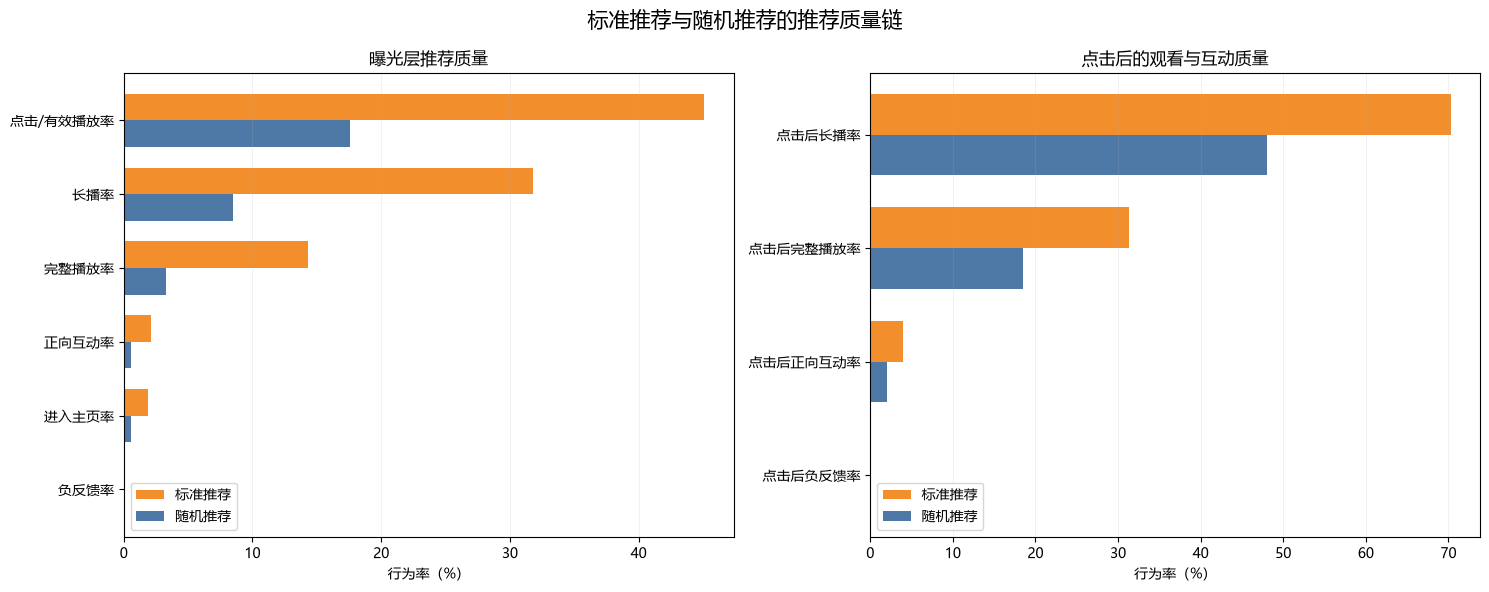

In [7]:

metric_order = [
    "点击/有效播放率", "长播率", "完整播放率",
    "正向互动率", "进入主页率", "负反馈率",
    "点击后长播率", "点击后完整播放率",
    "点击后正向互动率", "点击后负反馈率",
]
metric_rank = {metric: rank for rank, metric in enumerate(metric_order)}

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

for ax, level, title in [
    (axes[0], "exposure", "曝光层推荐质量"),
    (axes[1], "post_click", "点击后的观看与互动质量"),
]:
    plot_data = funnel_metrics[funnel_metrics["metric_level"] == level].copy()
    plot_data["_rank"] = plot_data["metric"].map(metric_rank)
#.map() 是 Pandas Series 的映射方法,它会取出 Series 中的每一个值，把它作为字典的键，查询对应的字典值。
    plot_data = plot_data.sort_values("_rank")
    y = np.arange(len(plot_data))
    width = 0.36
    ax.barh(
        y - width / 2,
        plot_data["standard_rate_pct"],
        height=width,
        color=COLORS["standard"],
        label="标准推荐",
    )
    ax.barh(
        y + width / 2,
        plot_data["random_rate_pct"],
        height=width,
        color=COLORS["random"],
        label="随机推荐",
    )
    ax.set_yticks(y, plot_data["metric"])
    ax.invert_yaxis()
    ax.set_xlabel("行为率（%）")
    ax.set_title(title)
    ax.grid(axis="x", alpha=0.25)
    ax.legend()

fig.suptitle("标准推荐与随机推荐的推荐质量链", fontsize=15)
fig.tight_layout()
fig.savefig(
    FIGURE_DIR / "business_01_quality_funnel.png",
    dpi=220,
    bbox_inches="tight",
)
plt.show()

## 四、共同用户配对验证

总体曝光加权结果容易受到“高曝光用户权重更大”的影响。本节对共同用户分别计算两种推荐方式下的行为率，再对每名用户的差值等权求平均。

95%置信区间以用户为重采样单位进行 Bootstrap，避免把同一用户的多条曝光误认为完全独立样本。

In [8]:
PAIRED_METRICS = {
    "is_click": "点击/有效播放率",
    "long_view": "长播率",
    "is_complete_play": "完整播放率",
    "has_interaction": "正向互动率",
    "is_hate": "负反馈率",
}

def bootstrap_mean_ci(
    values: np.ndarray,
    n_boot: int = 2000,
    batch_size: int = 100,
    seed: int = 42,
) -> tuple[float, float]:
    values = np.asarray(values, dtype="float64")
    values = values[np.isfinite(values)] #删除 NaN、正无穷和负无穷，只保留可以正常参与计算的有限数值。
    rng = np.random.default_rng(seed)  #创建一个 NumPy 随机数生成器，并使用前面传入的随机种子。
    boot_means = []
    n = len(values)

    for start in range(0, n_boot, batch_size):
        size = min(batch_size, n_boot - start)  #这行代码是为了兼容“总次数不能被批次大小整除”的情况
        indices = rng.integers(0, n, size=(size, n))
        boot_means.append(values[indices].mean(axis=1))
        #values[indices]：根据索引抽取差值。
        #20批完成后，boot_means 中有20个数组，每个数组通常包含100个平均值，即20个数组 × 每个100个平均值。np.concatenate() 将它们首尾连接成一个大数组。
    samples = np.concatenate(boot_means)
    return tuple(np.quantile(samples, [0.025, 0.975]))


standard_user_rates = (
    standard.groupby("user_id", observed=True)[list(PAIRED_METRICS.keys())]
    .mean()
)
random_user_rates = (
    random_data.groupby("user_id", observed=True)[list(PAIRED_METRICS.keys())]
    .mean()
)
#observed这个参数只在分组字段是 Pandas 的 category 类型时产生实际影响，即只保留实际出现的用户。
paired_users = standard_user_rates.join(
    random_user_rates,
    how="inner",
    lsuffix="_standard",
    rsuffix="_random",
)
display(paired_users)

,is_click_standard,long_view_standard,is_complete_play_standard,has_interaction_standard,is_hate_standard,is_click_random,long_view_random,is_complete_play_random,has_interaction_random,is_hate_random
user_id,,,,,,,,,,
0,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
1,0.2500,0.2500,0.0000,0.0000,0.0000,0.1364,0.1364,0.0909,0.0000,0.0000
2,0.3750,0.1250,0.0833,0.0000,0.0000,0.2917,0.2292,0.0851,0.0000,0.0000
3,0.4444,0.4444,0.2222,0.0000,0.0000,0.1667,0.0769,0.0263,0.0000,0.0000
4,0.3750,0.3750,0.2500,0.0000,0.0000,0.0172,0.0000,0.0000,0.0172,0.0000
...,...,...,...,...,...,...,...,...,...,...
27280,0.3871,0.1935,0.0323,0.0000,0.0000,0.0690,0.0345,0.0357,0.0000,0.0000
27281,0.2222,0.1111,0.0556,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
27282,0.6667,0.6667,0.0000,0.0000,0.0000,0.1111,0.0000,0.0000,0.0000,0.0000


In [9]:
assert len(paired_users) == 25_877

paired_rows = []
for column, label in PAIRED_METRICS.items():
    differences = (
        paired_users[f"{column}_standard"]
        - paired_users[f"{column}_random"]
    ).dropna().astype("float64") * 100

    ci_low, ci_high = bootstrap_mean_ci(differences)
    paired_rows.append({
        "metric": label,
        "paired_users": len(differences),
        "mean_gap_pp": differences.mean(),
        "median_gap_pp": differences.median(),
        "ci95_low_pp": ci_low,
        "ci95_high_pp": ci_high,
        "positive_user_share_pct": (differences > 0).mean() * 100,
        "negative_user_share_pct": (differences < 0).mean() * 100,
        "zero_user_share_pct": (differences == 0).mean() * 100,
    })

paired_validation = pd.DataFrame(paired_rows)
paired_validation.to_csv(
    OUTPUT_DIR / "paired_user_validation.csv",
    index=False,
    encoding="utf-8-sig",
)
display(paired_validation.round(4))

,metric,paired_users,mean_gap_pp,median_gap_pp,ci95_low_pp,ci95_high_pp,positive_user_share_pct,negative_user_share_pct,zero_user_share_pct
0,点击/有效播放率,25877,30.8294,30.1948,30.5021,31.1386,86.5827,9.8775,3.5398
1,长播率,25877,26.6308,24.0260,26.3075,26.9324,81.1609,10.2639,8.5752
2,完整播放率,25846,13.3569,8.3333,13.0996,13.6019,61.9438,14.6676,23.3885
3,正向互动率,25877,1.6340,0.0000,1.5421,1.7306,12.5903,7.1106,80.2991
4,负反馈率,25877,-0.0560,0.0000,-0.0784,-0.0339,0.4405,1.6578,97.9016


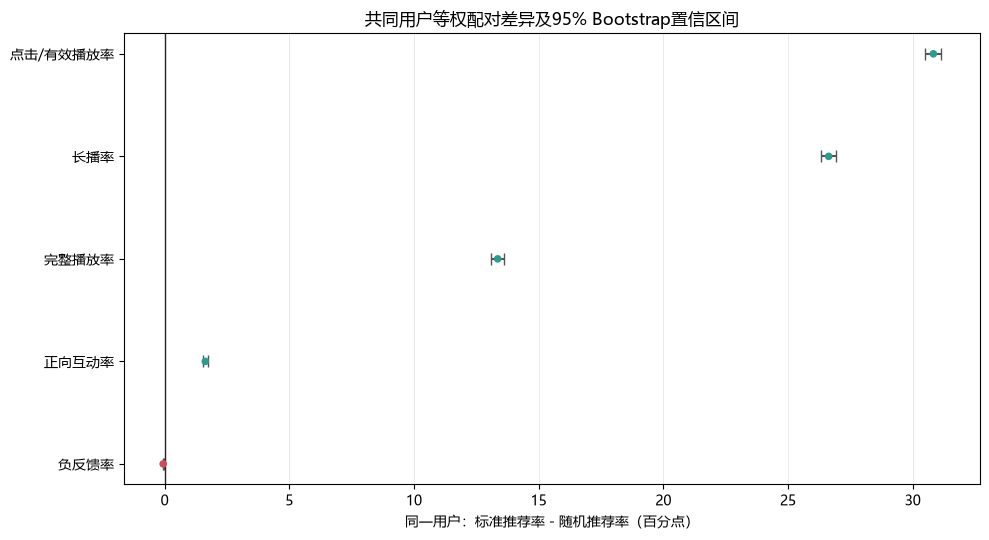

In [10]:
fig, ax = plt.subplots(figsize=(10, 5.5))
plot = paired_validation.iloc[::-1].copy()
x = plot["mean_gap_pp"]
xerr = np.vstack([
    x - plot["ci95_low_pp"],
    plot["ci95_high_pp"] - x,
])
colors = [
    COLORS["positive"] if value >= 0 else COLORS["negative"]
    for value in x
]
ax.errorbar(
    x,
    np.arange(len(plot)),
    xerr=xerr,
    fmt="none",
    ecolor="#555555",
    capsize=4,
    linewidth=1.5,
)
ax.scatter(x, np.arange(len(plot)), c=colors, s=20, zorder=3)  #Matplotlib 的绘制顺序就是由 zorder 控制，数值较大的对象会覆盖在数值较小的对象上
ax.axvline(0, color="#222222", linewidth=1)  #ax.axvline()：绘制竖直参考线,在x=0的位置画一条贯穿绘图区的竖线。
ax.set_yticks(np.arange(len(plot)), plot["metric"])
ax.set_xlabel("同一用户：标准推荐率 - 随机推荐率（百分点）")
ax.set_title("共同用户等权配对差异及95% Bootstrap置信区间")
ax.grid(axis="x", alpha=0.4)
fig.tight_layout()
fig.savefig(
    FIGURE_DIR / "business_03_paired_user_validation.png",
    dpi=220,
    bbox_inches="tight",
)
plt.show()

## 五、用户与内容分层

分层分析回答两个问题：

1. 推荐方式差异集中在哪些用户和内容群体？
2. 某个分组的高指标是否只是小样本波动？

稳定性门槛设为：两种推荐方式各不少于 1,000 条记录，且各不少于 100 名用户。未达到门槛的分组保留，但不用于普遍策略结论。

In [11]:
SEGMENT_DIMENSIONS = {
    "user_active_degree": "用户活跃度",
    "register_days_group": "注册时长",
    "duration_group": "视频时长",
    "video_type": "视频类型",
    "screen_orientation": "画面方向",
}

RATE_METRICS = {
    "is_click": "点击/有效播放率",
    "long_view": "长播率",
    "is_complete_play": "完整播放率",
    "has_interaction": "正向互动率",
    "is_hate": "负反馈率",
}

MIN_RECORDS_PER_METHOD = 1000
MIN_USERS_PER_METHOD = 100


def aggregate_segment(
    data: pd.DataFrame,
    segment_col: str,
) -> pd.DataFrame:
    working = data.copy()
    working["_segment_value"] = (
        working[segment_col].astype("string").fillna("缺失")
    )
    return (
        working.groupby(
            ["recommendation_method", "_segment_value"],
            observed=True,
            dropna=False,
        )
        .agg(
            recommendation_records=("user_id", "size"),
            unique_users=("user_id", "nunique"),
            unique_videos=("video_id", "nunique"),
            **{
                f"{metric}_rate": (metric, "mean")
                for metric in RATE_METRICS
            }
        )
        .reset_index()
    )


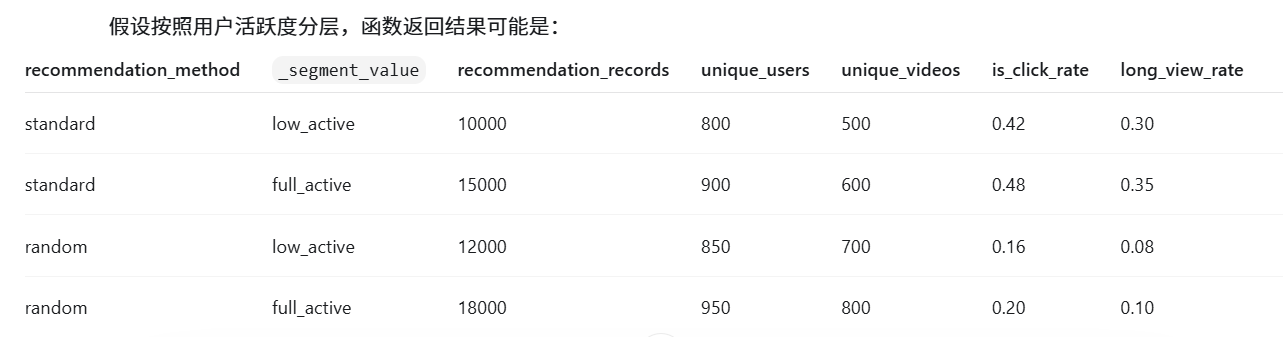

In [12]:
segment_rows = []
segment_aggregates = {}

for segment_col, segment_name in SEGMENT_DIMENSIONS.items():
    aggregate = aggregate_segment(all_data, segment_col)
    segment_aggregates[segment_col] = aggregate
    values = sorted(aggregate["_segment_value"].unique())

    for value in values:
        current = aggregate[aggregate["_segment_value"] == value]
        methods = set(current["recommendation_method"])
        if methods != {"standard", "random"}:
            continue
     #判断当前分层值是否同时拥有：standard，standom

        standard_row = current[
            current["recommendation_method"] == "standard"
        ].iloc[0]
        random_row = current[
            current["recommendation_method"] == "random"
        ].iloc[0]

        stable = (
            standard_row["recommendation_records"] >= MIN_RECORDS_PER_METHOD
            and random_row["recommendation_records"] >= MIN_RECORDS_PER_METHOD
            and standard_row["unique_users"] >= MIN_USERS_PER_METHOD
            and random_row["unique_users"] >= MIN_USERS_PER_METHOD
        )

        for metric, metric_name in RATE_METRICS.items():
            standard_rate = standard_row[f"{metric}_rate"] * 100
            random_rate = random_row[f"{metric}_rate"] * 100
            segment_rows.append({
                "segment_dimension": segment_name,
                "segment_column": segment_col,
                "segment_value": value,
                "metric": metric_name,
                "standard_records": int(standard_row["recommendation_records"]),
                "random_records": int(random_row["recommendation_records"]),
                "standard_users": int(standard_row["unique_users"]),
                "random_users": int(random_row["unique_users"]),
                "standard_videos": int(standard_row["unique_videos"]),
                "random_videos": int(random_row["unique_videos"]),
                "standard_rate_pct": standard_rate,
                "random_rate_pct": random_rate,
                "gap_pp": standard_rate - random_rate,
                "stable_for_strategy": stable,
            })

segment_gap_metrics = pd.DataFrame(segment_rows)
segment_gap_metrics.to_csv(
    OUTPUT_DIR / "segment_gap_metrics.csv",
    index=False,
    encoding="utf-8-sig",
)

display(segment_gap_metrics.head(10).round(4))

,segment_dimension,segment_column,segment_value,metric,standard_records,random_records,standard_users,random_users,standard_videos,random_videos,standard_rate_pct,random_rate_pct,gap_pp,stable_for_strategy
0,用户活跃度,user_active_degree,2_14_day_new,点击/有效播放率,7517,23214,613,635,2434,7066,47.7584,18.3941,29.3643,True
1,用户活跃度,user_active_degree,2_14_day_new,长播率,7517,23214,613,635,2434,7066,33.2313,8.8136,24.4177,True
2,用户活跃度,user_active_degree,2_14_day_new,完整播放率,7517,23214,613,635,2434,7066,15.3585,3.4269,11.9315,True
3,用户活跃度,user_active_degree,2_14_day_new,正向互动率,7517,23214,613,635,2434,7066,2.3813,0.6246,1.7566,True
4,用户活跃度,user_active_degree,2_14_day_new,负反馈率,7517,23214,613,635,2434,7066,0.0665,0.0991,-0.0326,True
5,用户活跃度,user_active_degree,30day_retention,点击/有效播放率,282,486,14,15,251,471,46.4539,13.7860,32.6679,False
6,用户活跃度,user_active_degree,30day_retention,长播率,282,486,14,15,251,471,33.6879,5.7613,27.9266,False
7,用户活跃度,user_active_degree,30day_retention,完整播放率,282,486,14,15,251,471,15.2174,2.3355,12.8819,False
8,用户活跃度,user_active_degree,30day_retention,正向互动率,282,486,14,15,251,471,1.0638,0.0000,1.0638,False
9,用户活跃度,user_active_degree,30day_retention,负反馈率,282,486,14,15,251,471,0.0000,0.0000,0.0000,False


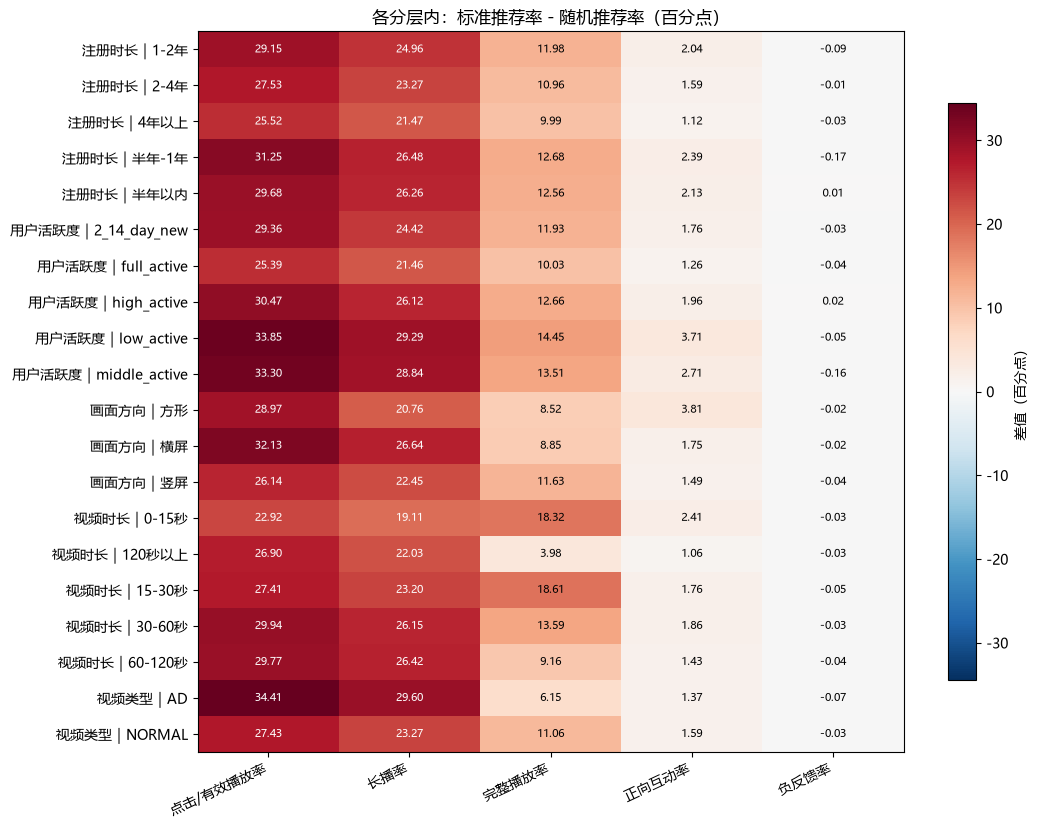

In [13]:
heatmap_metrics = [
    "点击/有效播放率",
    "长播率",
    "完整播放率",
    "正向互动率",
    "负反馈率",
]
stable_heatmap = (
    segment_gap_metrics[
        segment_gap_metrics["stable_for_strategy"] #代表样本量达到预设门槛，不等于差异一定具有统计显著性。
        & segment_gap_metrics["metric"].isin(heatmap_metrics)
        & segment_gap_metrics["segment_value"].ne("缺失")
    ]
    .pivot_table(
        index=["segment_dimension", "segment_value"], #用了两个索引列
        columns="metric",
        values="gap_pp",
    )    #把长表转换成热力图需要的宽表。即如果同一个：分层维度+分层取值+指标 对应了多条记录，pivot_table() 必须知道如何把多条记录汇总成一个格子。
    .reindex(columns=heatmap_metrics) #用于固定热力图的列顺序，且如果某个指标在筛选结果中完全不存在，也会保留对应列，只是该列的值为 NaN。
)

values = stable_heatmap.to_numpy(dtype="float64") #将 stable_heatmap 从 Pandas DataFrame 转换为二维 NumPy 数组。
limit = np.nanmax(np.abs(values))  #找最大值，并忽略 NaN。旨在确定热力图颜色范围。

fig_height = max(8, len(stable_heatmap) * 0.42)
#动态计算图片的高度。每一行分配约 0.42 英寸的高度
fig, ax = plt.subplots(figsize=(11, fig_height))

#绘制热力图
#imshow() 把二维数组的每个数值映射成一个彩色格子。
image = ax.imshow(
    values,
    cmap="RdBu_r",  #指定配色方案，RdBu：红蓝渐变，_r：reverse，反转原来的颜色方向
    aspect="auto", #允许系统自动调整格子的长宽比例，以便热力图填满整个坐标区域。
    vmin=-limit,  #规定颜色映射的最小值
    vmax=limit,  #规定颜色映射的最大值
)
#设置横轴刻度和指标名称
ax.set_xticks(np.arange(len(heatmap_metrics)), heatmap_metrics, rotation=25, ha="right")  #文字右对齐

#生成纵轴标签
row_labels = [
    f"{dimension}｜{value}"
    for dimension, value in stable_heatmap.index
]
ax.set_yticks(np.arange(len(row_labels)), row_labels)

#给每个格子写入数值
for i in range(values.shape[0]):
    for j in range(values.shape[1]):
        value = values[i, j]
        if np.isfinite(value):
            color = "white" if abs(value) > limit * 0.55 else "black"
            ax.text(j, i, f"{value:.2f}", ha="center", va="center", color=color, fontsize=8)
    #ax.text(x, y, ...)  ha="center"：水平方向居中   va="center"：垂直方向居中

ax.set_title("各分层内：标准推荐率 - 随机推荐率（百分点）")
#在图旁边添加颜色刻度条
#image：颜色条对应前面 imshow() 创建的热力图
#ax=ax：颜色条属于当前坐标区域
#label="差值（百分点）"：颜色条标题
# shrink=0.8：颜色条高度缩小为默认长度的80%
fig.colorbar(image, ax=ax, label="差值（百分点）", shrink=0.8)
fig.tight_layout()
fig.savefig(
    FIGURE_DIR / "business_02_segment_gap.png",
    dpi=220,
    bbox_inches="tight",
)
plt.show()

## 六、构成校正

如果标准推荐恰好包含更多高活跃用户或特定时长内容，总体差异可能只是样本构成不同。

这里分别按每个分层变量使用“标准+随机”的合并样本占比作为共同权重，再计算两种推荐方式的标准化指标。该方法只能削弱单一已观测变量的构成影响，不能替代随机实验。

In [14]:
COMPOSITION_METRICS = {
    "is_click": "点击/有效播放率",
    "long_view": "长播率",
    "is_complete_play": "完整播放率",
    "has_interaction": "正向互动率",
}

composition_rows = []

for segment_col, segment_name in SEGMENT_DIMENSIONS.items():
    aggregate = segment_aggregates[segment_col]

    #pivot()的作用在于：把长表转换成宽表
    for metric, metric_name in COMPOSITION_METRICS.items():
        rate_col = f"{metric}_rate"
        rate_table = aggregate.pivot(
            index="_segment_value",
            columns="recommendation_method",
            values=rate_col,
        ).dropna()
        #pivot() 要求每个“分层取值 × 推荐方式”组合只能对应一个值；如果存在重复记录，它会报错，而不会自动聚合。

        size_table = aggregate.pivot(
            index="_segment_value",
            columns="recommendation_method",
            values="recommendation_records",
        ).loc[rate_table.index]  #根据标签选取与 rate_table 相同的分层取值，并按照相同顺序排列，这样两个表后面计算时能够准确对齐。

        pooled_weights = (
            size_table["standard"] + size_table["random"]
        )
        pooled_weights = pooled_weights / pooled_weights.sum()

        adjusted_standard = (
            pooled_weights * rate_table["standard"]
        ).sum() * 100
        adjusted_random = (
            pooled_weights * rate_table["random"]
        ).sum() * 100

        raw_standard = standard[metric].mean() * 100
        raw_random = random_data[metric].mean() * 100
        raw_gap = raw_standard - raw_random
        adjusted_gap = adjusted_standard - adjusted_random

        composition_rows.append({
            "segment_dimension": segment_name,
            "segment_column": segment_col,
            "metric": metric_name,
            "raw_standard_rate_pct": raw_standard,
            "raw_random_rate_pct": raw_random,
            "raw_gap_pp": raw_gap,
            "adjusted_standard_rate_pct": adjusted_standard,
            "adjusted_random_rate_pct": adjusted_random,
            "adjusted_gap_pp": adjusted_gap,
            "adjustment_effect_pp": adjusted_gap - raw_gap,
        })

composition_adjustment = pd.DataFrame(composition_rows)
composition_adjustment.to_csv(
    OUTPUT_DIR / "composition_adjustment.csv",
    index=False,
    encoding="utf-8-sig",
)
display(composition_adjustment.round(4))

,segment_dimension,segment_column,metric,raw_standard_rate_pct,raw_random_rate_pct,raw_gap_pp,adjusted_standard_rate_pct,adjusted_random_rate_pct,adjusted_gap_pp,adjustment_effect_pp
0,用户活跃度,user_active_degree,点击/有效播放率,45.1171,17.6160,27.5011,44.7916,17.6388,27.1528,-0.3483
1,用户活跃度,user_active_degree,长播率,31.8329,8.4962,23.3367,31.5786,8.5067,23.0719,-0.2648
2,用户活跃度,user_active_degree,完整播放率,14.3247,3.3187,11.0060,14.2109,3.3217,10.8892,-0.1168
3,用户活跃度,user_active_degree,正向互动率,2.1431,0.5574,1.5857,2.0938,0.5590,1.5348,-0.0509
4,注册时长,register_days_group,点击/有效播放率,45.1171,17.6160,27.5011,45.0557,17.6224,27.4333,-0.0678
5,注册时长,register_days_group,长播率,31.8329,8.4962,23.3367,31.7819,8.4995,23.2824,-0.0543
6,注册时长,register_days_group,完整播放率,14.3247,3.3187,11.0060,14.2998,3.3198,10.9800,-0.0260
7,注册时长,register_days_group,正向互动率,2.1431,0.5574,1.5857,2.1315,0.5582,1.5733,-0.0124
8,视频时长,duration_group,点击/有效播放率,45.1171,17.6160,27.5011,45.0619,17.6347,27.4272,-0.0739
9,视频时长,duration_group,长播率,31.8329,8.4962,23.3367,31.7144,8.5215,23.1929,-0.1438


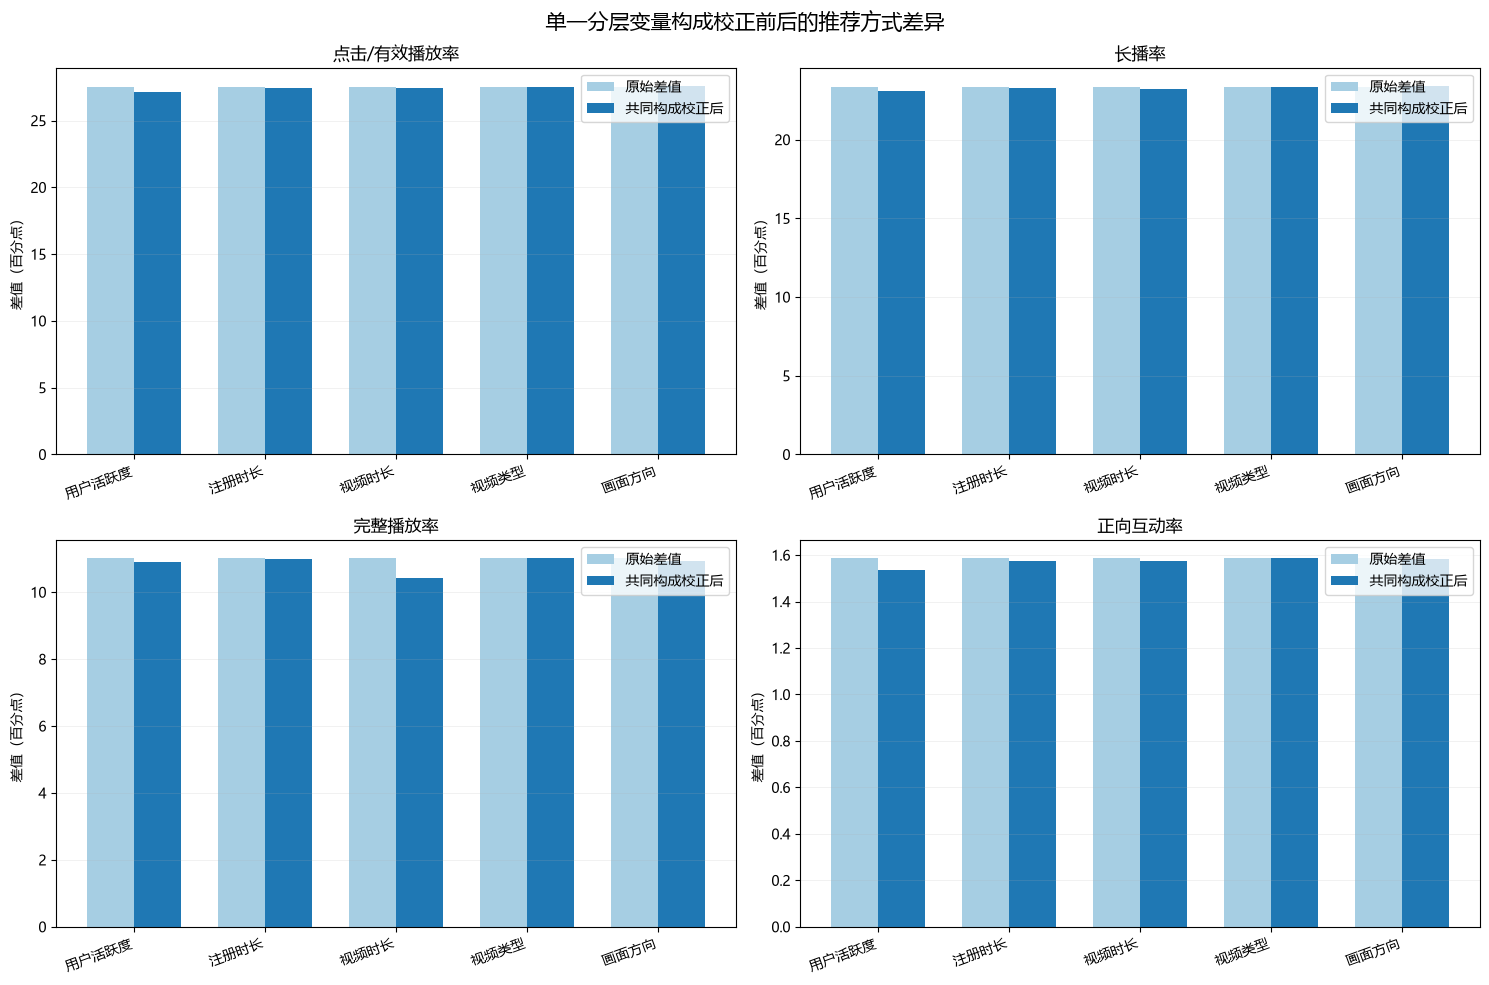

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
for ax, metric_name in zip(axes.flat, COMPOSITION_METRICS.values()):
    current = composition_adjustment[
        composition_adjustment["metric"] == metric_name
    ]
    x = np.arange(len(current))
    width = 0.36
    ax.bar(
        x - width / 2,
        current["raw_gap_pp"],
        width=width,
        label="原始差值",
        color="#A6CEE3",
    )
    ax.bar(
        x + width / 2,
        current["adjusted_gap_pp"],
        width=width,
        label="共同构成校正后",
        color="#1F78B4",
    )
    ax.set_xticks(x, current["segment_dimension"], rotation=20, ha="right")
    ax.set_ylabel("差值（百分点）")
    ax.set_title(metric_name)
    ax.grid(axis="y", alpha=0.25)
    ax.legend()

fig.suptitle("单一分层变量构成校正前后的推荐方式差异", fontsize=15)
fig.tight_layout()
fig.savefig(
    FIGURE_DIR / "business_04_composition_adjustment.png",
    dpi=220,
    bbox_inches="tight",
)
plt.show()

## 七、策略假设与A/B实验设计

前面的观察性分析只能用于发现值得验证的方向，不能直接证明策略具有因果增量。

本节形成三个处理方式、主指标和风险边界各不相同的实验假设。

三个实验均采用用户级随机分流，同一用户在整个实验周期内固定进入同一组，避免跨组污染。分层变量必须使用实验开始前的信息预先确定。

本节所说的“用户等权平均率”，是先计算每位用户自己的行为次数÷有效曝光次数，再对所有用户的该比例等权平均；它不同于直接用全组行为总次数÷全组曝光总次数计算的曝光加权总体率。

### 假设1：高活跃、长注册时长用户需要更强的新鲜度和探索性

如果标准推荐相对随机推荐的优势在高活跃、长注册时长用户中更小，可以提出待验证假设：长期使用可能带来兴趣收敛或内容疲劳；在标准推荐的基础上适度提高新作者、新主题和多样化内容的权重，可能改善这类用户的深度观看表现。

| 项目 | 实验设计 |
|---|---|
| 实验对象 | 在实验开始前按固定规则识别的高活跃、长注册时长用户；活跃度和注册时长阈值需预先冻结 |
| 随机化单位 | 用户级随机分流，同一用户固定在同一组 |
| 对照组 | 当前标准推荐策略 |
| 实验组 | 在当前标准推荐策略上，仅提高新作者、新主题、低重复内容或多样化内容的探索权重 |
| 主指标 | 用户等权平均长播率，用于判断新鲜度策略是否改善深度观看 |
| 次要指标 | 用户等权平均点击率、点击后长播率、正向互动率、人均观看时长 |
| 机制指标 | 新作者曝光占比、主题覆盖数、重复内容率、列表内多样性，确认实验处理确实生效 |
| 护栏指标 | 负反馈率、点击后负反馈率、快速退出率、推荐响应时延 |
| 分层检查 | 实验前用户活跃度、注册时长、历史兴趣集中度；若只研究目标人群，则在目标人群内部继续检查异质性 |
| 结论要求 | 主指标点估计达到预设业务MDE且95%置信区间支持正向效果；机制指标按预期变化；护栏指标不突破预设劣化界限 |

新作者曝光占比和内容多样性属于机制指标：它们可以证明实验组确实增加了探索，但不能单独证明用户体验已经改善。

### 假设2：提高30—120秒内容权重可以改善长播率

观察性分层结果显示，中等时长内容在点击和长播指标上具有值得进一步验证的表现。因此提出待验证假设：在其他推荐规则不变时，适度提高30—120秒内容的排序或曝光权重，可以提高整体深度观看表现。

| 项目 | 实验设计 |
|---|---|
| 实验对象 | 满足正常推荐条件且候选池中存在足量合格内容的用户 |
| 随机化单位 | 用户级随机分流，同一用户固定在同一组 |
| 对照组 | 当前标准推荐策略 |
| 实验组 | 在当前标准推荐策略上，仅提高30—120秒内容的排序或曝光权重 |
| 主指标 | 用户等权平均长播率 |
| 次要指标 | 用户等权平均点击率、点击后长播率、人均观看时长、正向互动率 |
| 机制指标 | 30—120秒内容曝光占比，确认时长结构确实发生预期变化 |
| 护栏指标 | 负反馈率、点击后负反馈率、完播率、快速划走率、推荐响应时延 |
| 分层检查 | 实验前用户活跃度、注册时长、历史观看时长偏好；不按实验后实际曝光到的内容时长筛选用户 |
| 结论要求 | 长播率点估计达到预设业务MDE且95%置信区间支持正向效果；30—120秒曝光占比按预期变化；护栏指标不突破预设劣化界限 |

这个实验检验的是“主动提高30—120秒内容权重能否改善长播”，而不是重复验证“历史样本中这类内容的长播率是否更高”。

### 假设3：提高0—30秒内容权重可以改善完播率

观察性分层结果显示，短内容更容易达到完整播放。因此提出待验证假设：在其他推荐规则不变时，适度提高0—30秒内容的排序或曝光权重，可以提高完播表现，同时不明显损害观看深度和整体满意度。

| 项目 | 实验设计 |
|---|---|
| 实验对象 | 满足正常推荐条件且候选池中存在足量合格短内容的用户 |
| 随机化单位 | 用户级随机分流，同一用户固定在同一组 |
| 对照组 | 当前标准推荐策略 |
| 实验组 | 在当前标准推荐策略上，仅提高0—30秒内容的排序或曝光权重 |
| 主指标 | 用户等权平均完整播放率 |
| 次要指标 | 用户等权平均点击率、点击后完整播放率、人均完整播放次数、正向互动率 |
| 机制指标 | 0—30秒内容曝光占比，确认短内容供给和曝光结构确实发生变化 |
| 护栏指标 | 人均观看时长、长播率、负反馈率、点击后负反馈率、快速划走率 |
| 分层检查 | 实验前用户活跃度、注册时长、历史观看时长偏好；不按实验后实际曝光到的内容时长筛选用户 |
| 结论要求 | 完播率点估计达到预设业务MDE且95%置信区间支持正向效果；人均观看时长、长播率和负反馈等护栏指标不突破预设劣化界限 |

短内容天然更容易完播，因此完播率提高不能被直接解释为“内容质量提高”。必须结合观看时长、长播率、互动和负反馈判断策略是否真正改善了用户体验。

### 三个实验的共同执行与结论规则

1. 每个实验只预先指定一个主指标，次要指标用于解释变化链路，护栏指标用于防止策略优化主指标时造成明显伤害。
2. 采用意向处理原则：按照用户最初被随机分配的组别进行比较，不因用户实际曝光量或是否看到目标内容而随意剔除。
3. 报告实验组与对照组的用户数、指标绝对差值、相对变化、95%置信区间、p值和实验周期，同时判断统计显著性和业务显著性。
4. 分层结论应优先检查组别与分层变量的交互作用，不能仅凭“一个分层显著、另一个分层不显著”断言两类用户效果不同。
5. 如果三个实验共享同一批用户、同一个对照组或同期运行，需要预先处理实验互斥和多重比较问题；也可以分阶段运行以减少策略之间的干扰。
6. 本项目不直接给出正式实验样本量。实际实施前，应根据历史用户级指标方差、用户内相关性和预计流量进行用户级样本量估计，并可通过A/A实验或小流量预实验校准。

> 结论边界：以上三个方向都是由历史观察性数据提出的待验证假设。只有完成可靠的用户级随机A/B实验后，才能判断对应策略是否产生因果增量。

## 八、自动生成的核心结论

下方结论直接引用本次运行结果，避免手工抄写造成口径漂移。

In [17]:
def get_paired(metric: str) -> pd.Series:
    return paired_validation.loc[
        paired_validation["metric"] == metric
    ].iloc[0]


def get_segment_gap(
    dimension: str,
    value: str,
    metric: str,
) -> float:
    row = segment_gap_metrics[
        (segment_gap_metrics["segment_dimension"] == dimension)
        & (segment_gap_metrics["segment_value"] == value)
        & (segment_gap_metrics["metric"] == metric)
    ]
    return float(row.iloc[0]["gap_pp"])


paired_click = get_paired("点击/有效播放率")
paired_long = get_paired("长播率")
paired_complete = get_paired("完整播放率")
paired_interaction = get_paired("正向互动率")
paired_hate = get_paired("负反馈率")

max_adjustment = float(
    composition_adjustment["adjustment_effect_pp"].abs().max()
)

conclusion = f"""
### 1. 多层质量指标方向一致

同期曝光加权口径下，标准推荐与随机推荐的点击率分别为
**{funnel_metrics.loc[funnel_metrics['metric'].eq('点击/有效播放率'), 'standard_rate_pct'].iloc[0]:.2f}%**
和
**{funnel_metrics.loc[funnel_metrics['metric'].eq('点击/有效播放率'), 'random_rate_pct'].iloc[0]:.2f}%**。
点击后长播率分别为
**{funnel_metrics.loc[funnel_metrics['metric'].eq('点击后长播率'), 'standard_rate_pct'].iloc[0]:.2f}%**
和
**{funnel_metrics.loc[funnel_metrics['metric'].eq('点击后长播率'), 'random_rate_pct'].iloc[0]:.2f}%**，
说明差异不仅体现在是否开始播放，也体现在开始播放后的观看质量。

### 2. 共同用户配对结果仍然支持方向一致的关联

在 **{len(paired_users):,}** 名共同用户中，标准推荐相对随机推荐的用户等权平均差异为：

- 点击/有效播放率：**{paired_click['mean_gap_pp']:.2f}** 个百分点，
  95% Bootstrap CI **[{paired_click['ci95_low_pp']:.2f}, {paired_click['ci95_high_pp']:.2f}]**；
- 长播率：**{paired_long['mean_gap_pp']:.2f}** 个百分点，
  CI **[{paired_long['ci95_low_pp']:.2f}, {paired_long['ci95_high_pp']:.2f}]**；
- 完整播放率：**{paired_complete['mean_gap_pp']:.2f}** 个百分点；
- 正向互动率：**{paired_interaction['mean_gap_pp']:.2f}** 个百分点；
- 负反馈率：**{paired_hate['mean_gap_pp']:.3f}** 个百分点。

### 3. 差异在用户和内容分层中并不均匀

- 用户活跃度：low_active 的点击率差异为
  **{get_segment_gap('用户活跃度', 'low_active', '点击/有效播放率'):.2f}** 个百分点，
  full_active 为
  **{get_segment_gap('用户活跃度', 'full_active', '点击/有效播放率'):.2f}** 个百分点。
  这支持“中低活跃用户可能更受益于兴趣匹配，高活跃用户需要更多新鲜度”的待验证假设。
- 注册时长：半年至1年用户的点击率差异为
  **{get_segment_gap('注册时长', '半年-1年', '点击/有效播放率'):.2f}** 个百分点，
  4年以上用户为
  **{get_segment_gap('注册时长', '4年以上', '点击/有效播放率'):.2f}** 个百分点。
- 内容时长：60—120秒内容的点击率差异为
  **{get_segment_gap('视频时长', '60-120秒', '点击/有效播放率'):.2f}** 个百分点；
  15—30秒内容的完整播放率差异为
  **{get_segment_gap('视频时长', '15-30秒', '完整播放率'):.2f}** 个百分点。
  点击/长播目标和完播目标应采用不同的内容策略。

### 4. 单一构成变量不能解释总体差异

分别按用户活跃度、注册时长、视频时长、视频类型和画面方向使用共同构成权重校正后，
指标差异相对原始结果的最大变化只有 **{max_adjustment:.2f}** 个百分点。
这说明总体差异不是由上述某一个单一构成变量完全造成的；但未观测混杂、曝光位置和推荐机制仍然存在。

### 5. 结论边界

两组只有 **{common_pair_count}** 个共同“用户—视频”组合，且没有用户级随机分流信息。
因此本项目只能说明标准推荐在同期历史样本中与更好的多层行为指标相关，
不能证明推荐策略产生了因果增量。下一步应通过用户级随机A/B实验验证策略假设。
"""

display(Markdown(conclusion))


### 1. 多层质量指标方向一致

同期曝光加权口径下，标准推荐与随机推荐的点击率分别为
**45.12%**
和
**17.62%**。
点击后长播率分别为
**70.31%**
和
**48.06%**，
说明差异不仅体现在是否开始播放，也体现在开始播放后的观看质量。

### 2. 共同用户配对结果仍然支持方向一致的关联

在 **25,877** 名共同用户中，标准推荐相对随机推荐的用户等权平均差异为：

- 点击/有效播放率：**30.83** 个百分点，
  95% Bootstrap CI **[30.50, 31.14]**；
- 长播率：**26.63** 个百分点，
  CI **[26.31, 26.93]**；
- 完整播放率：**13.36** 个百分点；
- 正向互动率：**1.63** 个百分点；
- 负反馈率：**-0.056** 个百分点。

### 3. 差异在用户和内容分层中并不均匀

- 用户活跃度：low_active 的点击率差异为
  **33.85** 个百分点，
  full_active 为
  **25.39** 个百分点。
  这支持“中低活跃用户可能更受益于兴趣匹配，高活跃用户需要更多新鲜度”的待验证假设。
- 注册时长：半年至1年用户的点击率差异为
  **31.25** 个百分点，
  4年以上用户为
  **25.52** 个百分点。
- 内容时长：60—120秒内容的点击率差异为
  **29.77** 个百分点；
  15—30秒内容的完整播放率差异为
  **18.61** 个百分点。
  点击/长播目标和完播目标应采用不同的内容策略。

### 4. 单一构成变量不能解释总体差异

分别按用户活跃度、注册时长、视频时长、视频类型和画面方向使用共同构成权重校正后，
指标差异相对原始结果的最大变化只有 **0.59** 个百分点。
这说明总体差异不是由上述某一个单一构成变量完全造成的；但未观测混杂、曝光位置和推荐机制仍然存在。

### 5. 结论边界

两组只有 **136** 个共同“用户—视频”组合，且没有用户级随机分流信息。
因此本项目只能说明标准推荐在同期历史样本中与更好的多层行为指标相关，
不能证明推荐策略产生了因果增量。下一步应通过用户级随机A/B实验验证策略假设。
